<a href="{{ colab_base_laboratorios }}/Laboratorio_01_pinguinos_v2.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pylab as plt
import seaborn as sns

In [20]:
# Cargar el dataset
df = sns.load_dataset('penguins')

# parte A

In [6]:
# 1) ¿Cuántas filas y columnas tiene el dataset?
num_rows, num_cols = df.shape
print(f"El dataset tiene {num_rows} filas y {num_cols} columnas.")

El dataset tiene 344 filas y 7 columnas.


In [7]:
# 2) ¿Qué variables son numéricas y cuáles categóricas?
print("Información general del dataset (incluyendo tipos de datos):")
display(df.info())

Información general del dataset (incluyendo tipos de datos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


None

In [8]:
#3) ¿Cuántos valores faltantes hay por columna?
print("Valores faltantes por columna:")
display(df.isnull().sum())

Valores faltantes por columna:


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [9]:
# 4) ¿Existen filas duplicadas?
num_duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicates}")

Número de filas duplicadas: 0


In [10]:
# 5) ¿Qué variables tienen baja cardinalidad?
print("Cardinalidad de cada columna (número de valores únicos):")
for col in df.columns:
    print(f"- {col}: {df[col].nunique()} valores únicos")

Cardinalidad de cada columna (número de valores únicos):
- species: 3 valores únicos
- island: 3 valores únicos
- bill_length_mm: 164 valores únicos
- bill_depth_mm: 80 valores únicos
- flipper_length_mm: 55 valores únicos
- body_mass_g: 94 valores únicos
- sex: 2 valores únicos


# parte B

In [11]:
# 6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
print("Estadísticas descriptivas para variables numéricas:")

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=np.number)

# Calcular media, mediana, desviación estándar
descriptive_stats = numeric_cols.agg(['mean', 'median', 'std']).transpose()

# Calcular rango intercuartílico (IQR)
iqr = numeric_cols.quantile(0.75) - numeric_cols.quantile(0.25)
descriptive_stats['IQR'] = iqr

display(descriptive_stats)

Estadísticas descriptivas para variables numéricas:


,mean,median,std,IQR
bill_length_mm,43.921930,44.45,5.459584,9.275
bill_depth_mm,17.151170,17.30,1.974793,3.100
flipper_length_mm,200.915205,197.00,14.061714,23.000
body_mass_g,4201.754386,4050.00,801.954536,1200.000


In [12]:
# 7) Para cada variable categórica, reporte conteos y porcentajes.
print("Conteo y porcentajes para variables categóricas:")

categorical_cols = df.select_dtypes(include='object')

for col in categorical_cols.columns:
    print(f"\n--- Variable: {col} ---")
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(dropna=False, normalize=True) * 100

    # Combinar conteos y porcentajes en un solo DataFrame para una mejor visualización
    category_summary = pd.DataFrame({'Count': counts, 'Percentage': percentages})
    display(category_summary)

Conteo y porcentajes para variables categóricas:

--- Variable: species ---


,Count,Percentage
species,,
Adelie,152,44.186047
Gentoo,124,36.046512
Chinstrap,68,19.767442



--- Variable: island ---


,Count,Percentage
island,,
Biscoe,168,48.837209
Dream,124,36.046512
Torgersen,52,15.116279



--- Variable: sex ---


,Count,Percentage
sex,,
Male,168,48.837209
Female,165,47.965116
NaN,11,3.197674


In [13]:
#  8) Construya tablas cruzadas para pares de variables categóricas relevantes.
print("Tablas cruzadas para pares de variables categóricas:")

# Ejemplos de tablas cruzadas relevantes
# Puedes ajustar los pares de variables según tu interés

print("\n--- Especies vs. Isla ---")
display(pd.crosstab(df['species'], df['island']))

print("\n--- Especies vs. Sexo ---")
display(pd.crosstab(df['species'], df['sex']))

print("\n--- Isla vs. Sexo ---")
display(pd.crosstab(df['island'], df['sex']))

Tablas cruzadas para pares de variables categóricas:

--- Especies vs. Isla ---


island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0



--- Especies vs. Sexo ---


sex,Female,Male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61



--- Isla vs. Sexo ---


sex,Female,Male
island,,
Biscoe,80,83
Dream,61,62
Torgersen,24,23


In [14]:
# 9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.
print("Matriz de correlación de Pearson para variables numéricas:")
correlation_matrix_pearson = df.select_dtypes(include=np.number).corr(method='pearson')
display(correlation_matrix_pearson)

print("\nMatriz de correlación de Spearman para variables numéricas:")
correlation_matrix_spearman = df.select_dtypes(include=np.number).corr(method='spearman')
display(correlation_matrix_spearman)

Matriz de correlación de Pearson para variables numéricas:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000



Matriz de correlación de Spearman para variables numéricas:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.221749,0.672772,0.583800
bill_depth_mm,-0.221749,1.000000,-0.523267,-0.432372
flipper_length_mm,0.672772,-0.523267,1.000000,0.839974
body_mass_g,0.583800,-0.432372,0.839974,1.000000


# Parte C

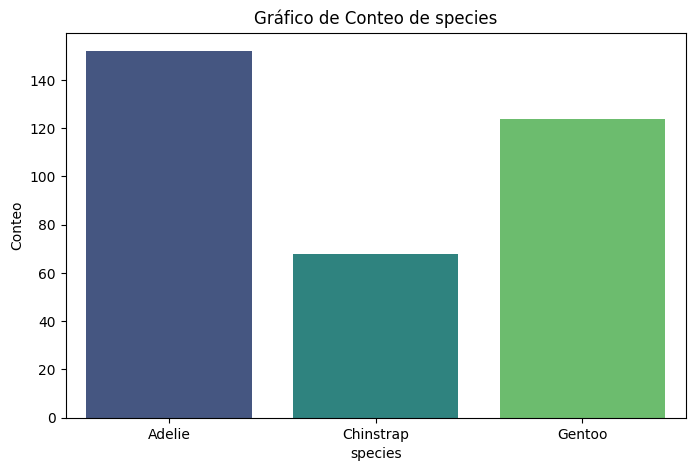

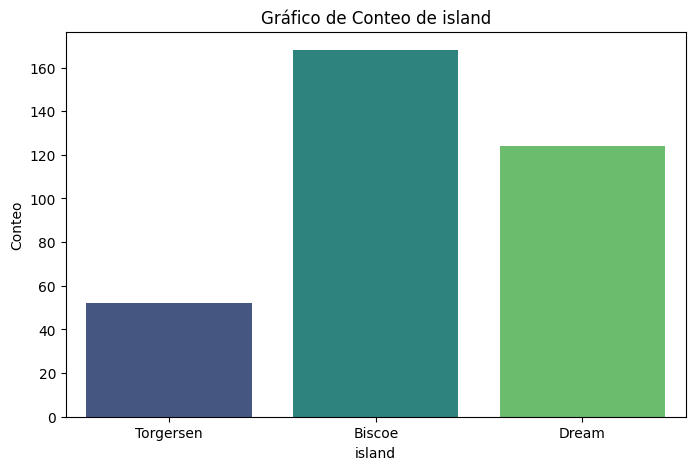

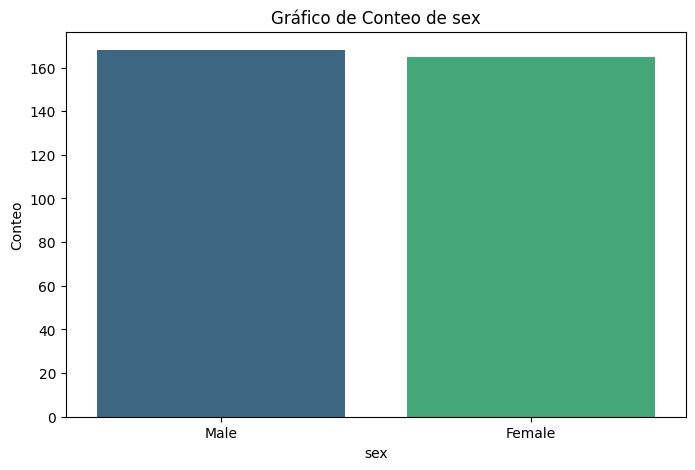

In [15]:
#10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
low_cardinality_cat_cols = ['species', 'island', 'sex']

for col in low_cardinality_cat_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.title(f'Gráfico de Conteo de {col}')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.show()

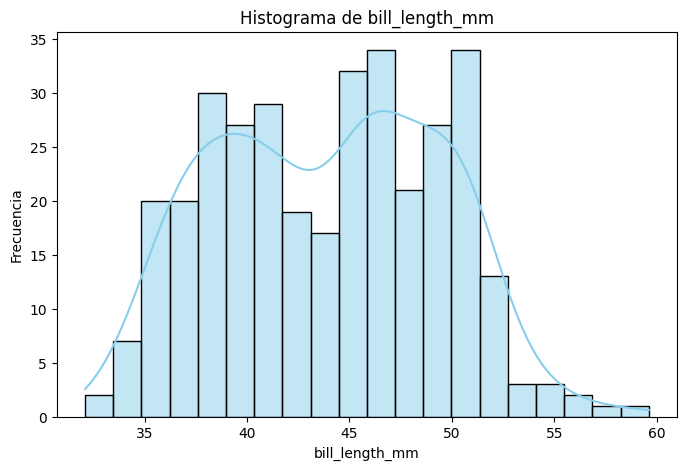

Descripción del histograma para bill_length_mm:
- Media: 43.92
- Mediana: 44.45
- Desviación estándar: 5.46




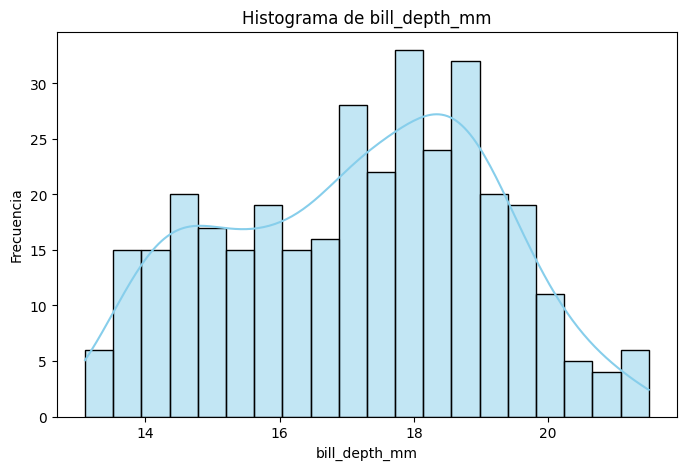

Descripción del histograma para bill_depth_mm:
- Media: 17.15
- Mediana: 17.30
- Desviación estándar: 1.97




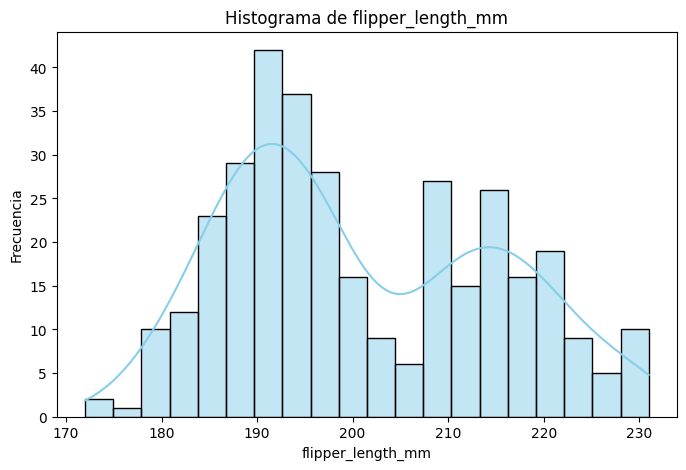

Descripción del histograma para flipper_length_mm:
- Media: 200.92
- Mediana: 197.00
- Desviación estándar: 14.06




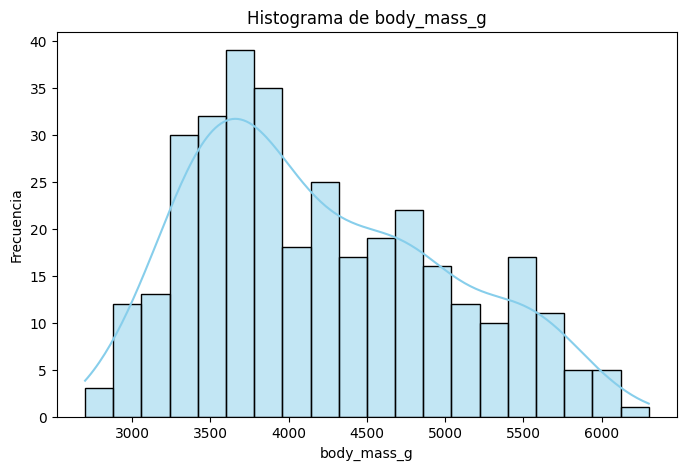

Descripción del histograma para body_mass_g:
- Media: 4201.75
- Mediana: 4050.00
- Desviación estándar: 801.95




In [16]:
#11) Genere histogramas para variables numéricas y describa su forma.
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True, bins=20, color='skyblue')
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()
    print(f"Descripción del histograma para {col}:")
    print(f"- Media: {df[col].mean():.2f}")
    print(f"- Mediana: {df[col].median():.2f}")
    print(f"- Desviación estándar: {df[col].std():.2f}")
    print("\n")

/tmp/ipykernel_5739/732744134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='bill_length_mm', palette='muted')


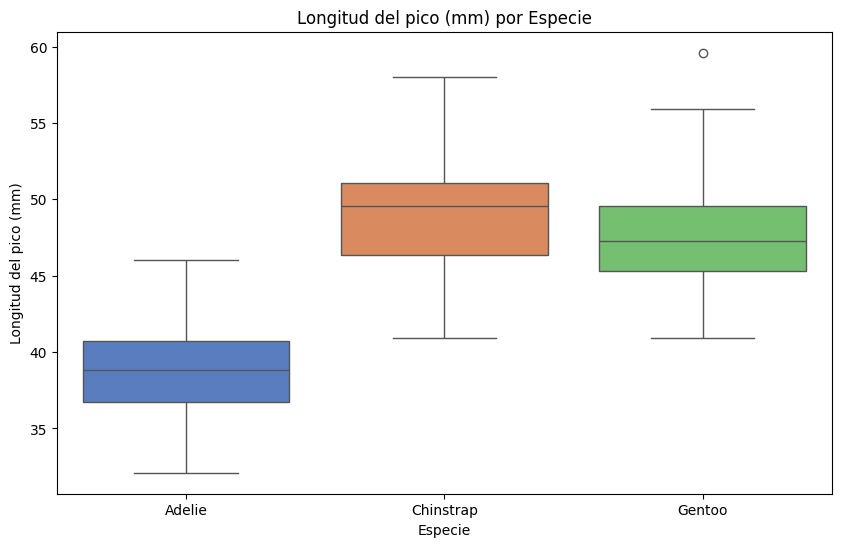

/tmp/ipykernel_5739/732744134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='body_mass_g', palette='muted')


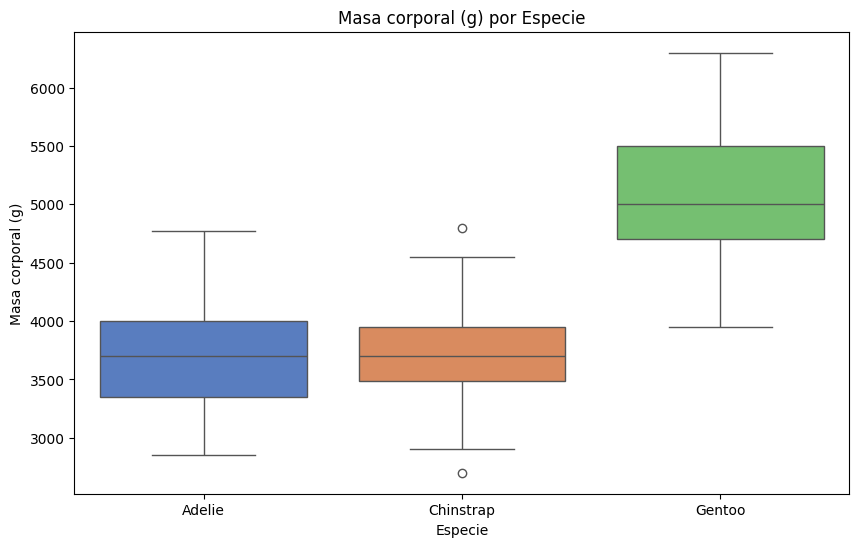

In [17]:
#12) Genere boxplots de una variable numérica por categoría (p. ej., bill_length_mm por species).
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='species', y='bill_length_mm', palette='muted')
plt.title('Longitud del pico (mm) por Especie')
plt.xlabel('Especie')
plt.ylabel('Longitud del pico (mm)')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='species', y='body_mass_g', palette='muted')
plt.title('Masa corporal (g) por Especie')
plt.xlabel('Especie')
plt.ylabel('Masa corporal (g)')
plt.show()

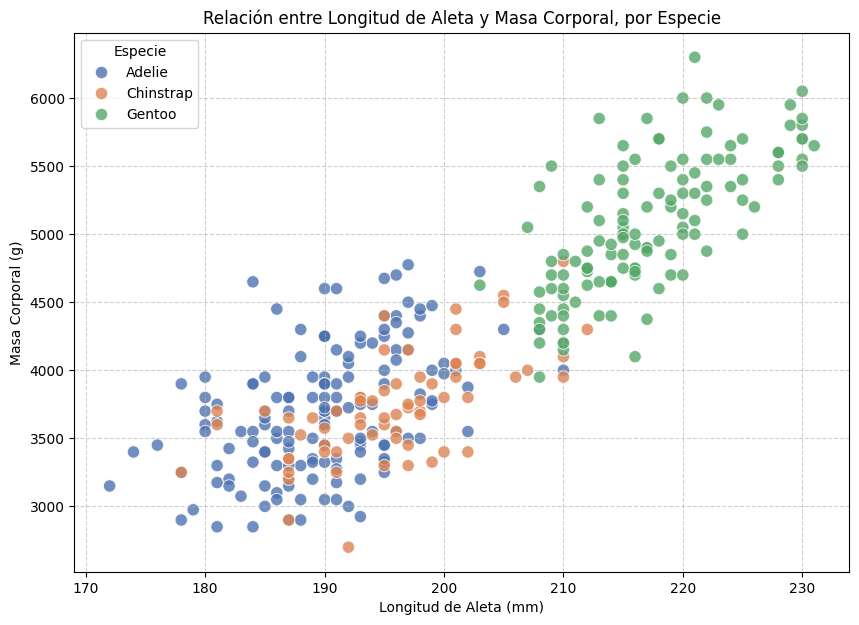

In [18]:
# 13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species', palette='deep', s=80, alpha=0.8)
plt.title('Relación entre Longitud de Aleta y Masa Corporal, por Especie')
plt.xlabel('Longitud de Aleta (mm)')
plt.ylabel('Masa Corporal (g)')
plt.legend(title='Especie')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

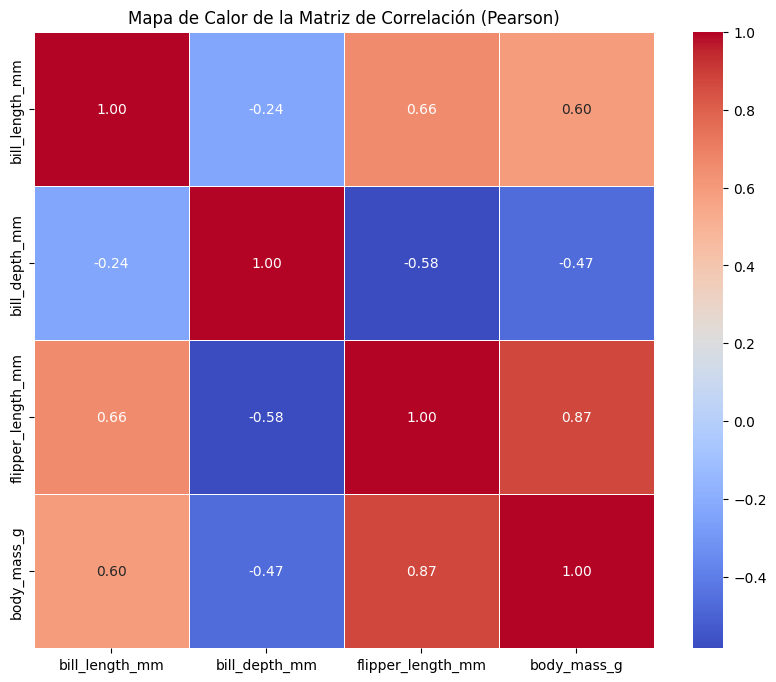

In [19]:
#14) Genere un heatmap de correlación.
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_pearson, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación (Pearson)')
plt.show()

# Parte D

## 15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.

Basándonos en la exploración previa, podemos proponer las siguientes hipótesis:


Hipótesis 1: Existe una correlación positiva fuerte entre
la longitud de la aleta (flipper_length_mm) y la masa corporal (body_mass_g), sugiriendo que aletas más largas corresponden a individuos de mayor peso.


Hipótesis 2: La longitud del pico (bill_length_mm) presenta diferencias significativas entre las distintas especies (species), siendo los pingüinos Gentoo y Chinstrap los que poseen picos más largos en comparación con los Adelie.



Hipótesis 3: La distribución de las especies (species) no es uniforme a través de las islas, sugiriendo una asociación entre el tipo de especie y la isla (island) donde habitan (por ejemplo, los pingüinos Gentoo solo se encuentran en la isla Biscoe).


Hipótesis 4: Existe una diferencia significativa en la profundidad del pico (bill_depth_mm) entre las especies, donde los pingüinos Gentoo tienden a tener picos menos profundos que los Adelie y Chinstrap.


Hipótesis 5: Dentro de cada especie, los machos presentan una masa corporal (body_mass_g) significativamente mayor que las hembras (dimorfismo sexual).


Hipótesis 6: La longitud de la aleta (flipper_length_mm) varía significativamente entre especies, siendo la especie Gentoo la que posee, en promedio, las aletas más largas.

# Parte E

In [21]:
from scipy import stats

# Preparar datos sin valores nulos para las pruebas
df_clean = df.dropna()

print("16, 17 y 18) Ejecución de Pruebas Estadísticas:\n")

# --- Prueba 1: Flipper Length vs Body Mass (Pearson) ---
corr, p_val = stats.pearsonr(df_clean['flipper_length_mm'], df_clean['body_mass_g'])
print(f"Hipótesis 1 (Correlación): Pearson={corr:.4f}, p-valor={p_val:.4g}")
if p_val < 0.05:
    print("Evidencia: Apoya la hipótesis (correlación significativa).")
else:
    print("Evidencia: No apoya la hipótesis.")

# --- Prueba 2: Bill Length por Species (ANOVA) ---
groups = [df_clean[df_clean['species'] == s]['bill_length_mm'] for s in df_clean['species'].unique()]
f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"\nHipótesis 2 (ANOVA): F-statistic={f_stat:.4f}, p-valor={p_val_anova:.4g}")
if p_val_anova < 0.05:
    print("Evidencia: Apoya la hipótesis (existen diferencias significativas entre especies).")
else:
    print("Evidencia: No apoya la hipótesis.")

# --- Prueba 3: Species vs Island (Chi-cuadrado) ---
contingency_table = pd.crosstab(df_clean['species'], df_clean['island'])
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nHipótesis 3 (Chi-cuadrado): Chi2={chi2:.4f}, p-valor={p_val_chi2:.4g}")
if p_val_chi2 < 0.05:
    print("Evidencia: Apoya la hipótesis (hay asociación entre especie e isla).")
else:
    print("Evidencia: No apoya la hipótesis.")

16, 17 y 18) Ejecución de Pruebas Estadísticas:

Hipótesis 1 (Correlación): Pearson=0.8730, p-valor=3.133e-105
Evidencia: Apoya la hipótesis (correlación significativa).

Hipótesis 2 (ANOVA): F-statistic=397.2994, p-valor=1.381e-88
Evidencia: Apoya la hipótesis (existen diferencias significativas entre especies).

Hipótesis 3 (Chi-cuadrado): Chi2=284.5900, p-valor=2.282e-60
Evidencia: Apoya la hipótesis (hay asociación entre especie e isla).


# Parte F



## 19) Redacción de conclusiones en tres capas

**A) Hallazgos descriptivos (con evidencia)**
*   El dataset cuenta con 344 registros y 7 variables. Se identificó una cantidad menor de valores faltantes, principalmente en la variable `sex` (3.2%).
*   La masa corporal promedio de los pingüinos es de aproximadamente 4201.75g, con una desviación estándar considerable de 801.95g, lo que indica una alta variabilidad en el tamaño de los individuos.
*   Existe una distribución desigual de especies, siendo *Adelie* la más frecuente (152 individuos) y *Chinstrap* la menos frecuente (68 individuos).

**B) Patrones visuales (con evidencia)**
*   **Correlación Fuerte:** Los diagramas de dispersión y la matriz de correlación confirman una relación lineal positiva muy fuerte entre `flipper_length_mm` y `body_mass_g` (Pearson = 0.87).
*   **Segregación por Especie:** Los boxplots muestran que la especie *Gentoo* es claramente distinta en términos de masa corporal y longitud de aleta (siendo significativamente más grandes).
*   **Especialización por Isla:** Se observó visualmente (y se confirmó con Chi-cuadrado) que ciertas especies están restringidas a islas específicas; por ejemplo, los pingüinos *Gentoo* solo habitan en la isla *Biscoe*.

**C) Próximas hipótesis a probar**
*   ¿Influye la isla de origen en la masa corporal final, controlando por la especie?
*   ¿Existe una interacción significativa entre el sexo y la especie en la profundidad del pico?
*   ¿El año de recolección de datos muestra alguna tendencia climática que afecte el tamaño de las poblaciones?

## 20) Preguntas para un investigador humano

*   **Manejo de Nulos:** ¿Existe una razón biológica por la cual el sexo de algunos individuos no pudo ser determinado, o es un error aleatorio de muestreo?
*   **Control por Especie:** Dado que las especies tienen tamaños base muy distintos, ¿deberíamos normalizar las medidas antes de realizar comparaciones entre islas?
*   **Contexto Geográfico:** ¿Hay diferencias en la disponibilidad de alimento entre las islas *Biscoe*, *Dream* y *Torgersen* que expliquen la segregación de especies?